In [ ]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


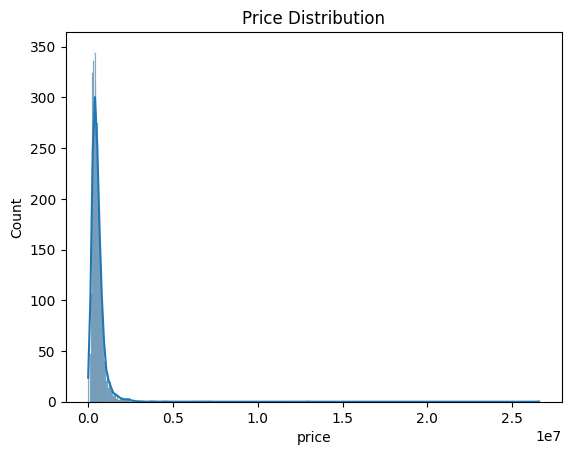

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

HEAD:
                   date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                

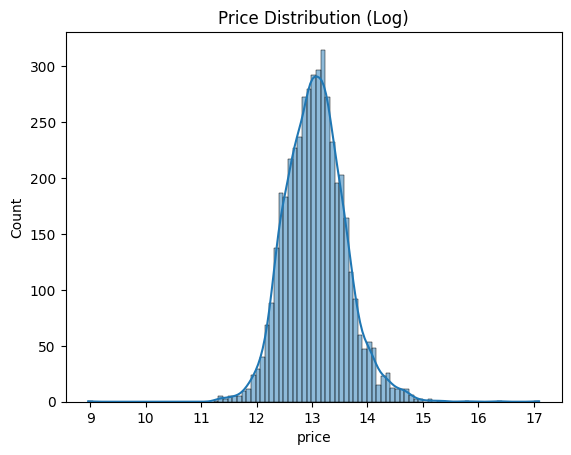

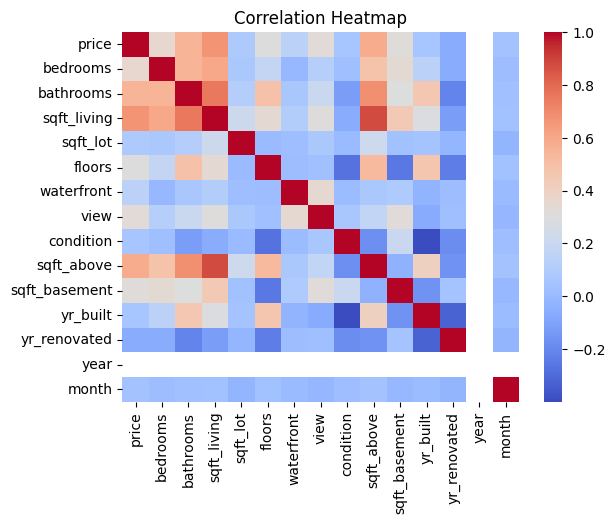

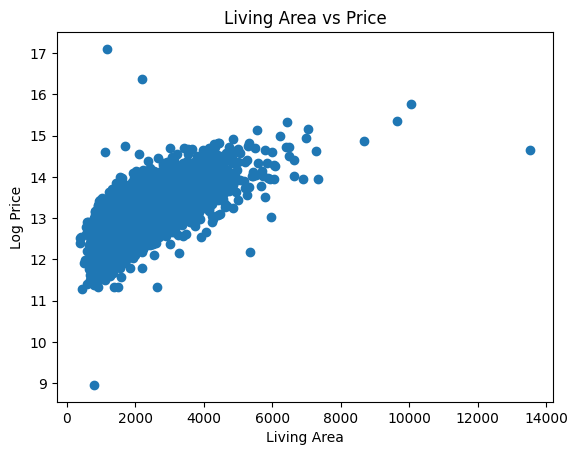


Linear Regression
RMSE: 0.2732996506062031
MAE: 0.165845211901509

Random Forest
RMSE: 0.28344040996672104
MAE: 0.18521940491205335

Gradient Boosting
RMSE: 0.2852644090005693
MAE: 0.19472449010419718


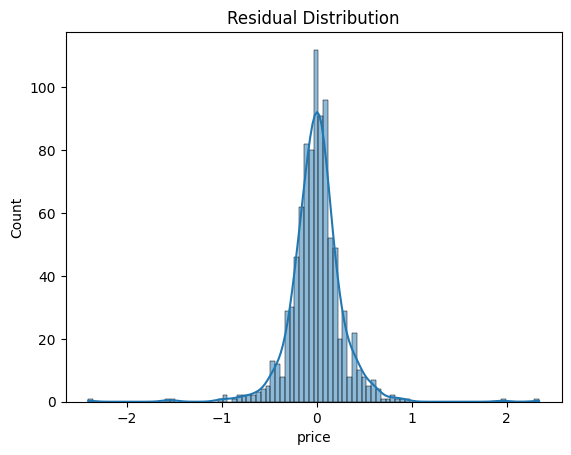


Predicted Price (log): [13.86079128]


In [14]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import joblib

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("data.csv")

print("HEAD:\n", df.head())
print("\nINFO:\n")
df.info()
print("\nMISSING VALUES:\n", df.isnull().sum())

# =========================
# DROP USELESS COLUMNS
# =========================
df.drop(['street', 'country'], axis=1, inplace=True, errors='ignore')

# =========================
# HANDLE DATE
# =========================
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df.drop('date', axis=1, inplace=True)

# =========================
# HANDLE MISSING VALUES
# =========================
df.fillna(df.mean(numeric_only=True), inplace=True)

# =========================
# ENCODING
# =========================
df = pd.get_dummies(df, columns=['city', 'statezip'], drop_first=True)

# =========================
# LOG TRANSFORMATION
# =========================
df = df[df['price'] > 0]
df['price'] = np.log(df['price'])

# =========================
# VISUALIZATION
# =========================

# Price distribution
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution (Log)")
plt.show()

# Correlation heatmap
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Scatter plot
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel("Living Area")
plt.ylabel("Log Price")
plt.title("Living Area vs Price")
plt.show()

# =========================
# DEFINE X AND y
# =========================
X = df.drop('price', axis=1)
y = df['price']

# =========================
# SCALING
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# =========================
# MODEL TRAINING
# =========================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Gradient Boosting
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# =========================
# EVALUATION
# =========================
def evaluate(name, y_test, pred):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("Gradient Boosting", y_test, gb_pred)

# =========================
# RESIDUAL ANALYSIS
# =========================
residuals = y_test - rf_pred

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# =========================
# SAVE MODEL
# =========================
joblib.dump(rf, "house_model.pkl")

# =========================
# INFERENCE
# =========================
loaded_model = joblib.load("house_model.pkl")

sample = [X_test[0]]
prediction = loaded_model.predict(sample)

print("\nPredicted Price (log):", prediction)